# Step 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print('Decision Tree Libraries Imported Successfully')

Decision Tree Libraries Imported Successfully


# Step 2: Load the Dataset

In [ ]:
df = pd.read_csv('/content/Employee Attrition.csv')

In [ ]:
# Display First 5 Rows
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
# Display Last 5 Rows
df.tail()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left
59597,15796,56,Male,19,Technology,6660,Good,High,Average,0,...,3,Mid,Medium,81,No,No,No,Good,Low,Stayed


In [ ]:
print('Dataset:')
df.shape

Dataset:


(59598, 24)

In [ ]:
print('Number of Columns:', len(df.columns))
print('\nAll Dataset Columns:')
print(df.columns.tolist())

Number of Columns: 24

All Dataset Columns:
['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


# Step 3: Separate Features and Target

We should exclude Employee ID because it is an identifier, not a meaningful predictive feature.

In [ ]:
X = df.drop(['Employee ID', 'Attrition'], axis=1)
y = df['Attrition']

print('Feature Shape:', X.shape)
print('Target Shape:', y.shape)

print('\nFeature Columns:')
print(X.columns.tolist())

print('\nTarget Values:')
print(y.unique())

Feature Shape: (59598, 22)
Target Shape: (59598,)

Feature Columns:
['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Target Values:
['Stayed' 'Left']


# Step 4: Target Distribution

In [ ]:
print('Attrition Value Counts:')
print(y.value_counts())

print('\nAttrition Percentage:')
print(y.value_counts(normalize=True) * 100)

Attrition Value Counts:
Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

Attrition Percentage:
Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


# Step 5: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state= 42, stratify = y)

print('Training Feature Shape:', X_train.shape)
print('Testing Feature Shape:', X_test.shape)

print('\nTraining Target Shape:', y_train.shape)
print('Testing Target Shape:', y_test.shape)

print('\nTraining Target Distribution:')
print(y_train.value_counts())

print('\nTesting Target Distribution:')
print(y_test.value_counts())

Training Feature Shape: (47678, 22)
Testing Feature Shape: (11920, 22)

Training Target Shape: (47678,)
Testing Target Shape: (11920,)

Training Target Distribution:
Attrition
Stayed    25008
Left      22670
Name: count, dtype: int64

Testing Target Distribution:
Attrition
Stayed    6252
Left      5668
Name: count, dtype: int64


# Step 6: Identify Numerical and Categorical Features

In [ ]:
numerical_features = X.select_dtypes(include= ['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include= ['object']).columns.tolist()

print('Numerical Features:')
print(numerical_features)
print('\nNumber of Numerical Features:', len(numerical_features))

print('\nCategorical Features:')
print(categorical_features)
print('\nNumber of Categorical Features:', len(categorical_features))

Numerical Features:
['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']

Number of Numerical Features: 7

Categorical Features:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Number of Categorical Features: 15


# Step 7: Create Preprocessing Pipeline


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers= [
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False), categorical_features)
    ]
)

print('Preprocessing Pipeline Created Successfully')
print('=' * 50)
print('Numerical Features:', len(numerical_features))
print('Categorical Features:', len(categorical_features))

Preprocessing Pipeline Created Successfully
Numerical Features: 7
Categorical Features: 15


# Step 8: Create Baseline Decision Tree Pipeline

- This is important because later we'll be able to clearly determine whether hyperparameter tuning actually improved the model.

In [ ]:
from sklearn.pipeline import Pipeline

baseline_dt = Pipeline(
    steps= [
        ('preprocessor', preprocessor),
        ('dt', DecisionTreeClassifier(random_state = 42))
    ]
)

print('Decision Tree Pipeline Created Successfully')
print('=' * 50)
print('Model: Decision Tree Classifier')
print('Random State: 42')

Decision Tree Pipeline Created Successfully
Model: Decision Tree Classifier
Random State: 42


# Step 9: Train Baseline Decision Tree

In [ ]:
baseline_dt.fit(X_train, y_train)

print('Decision Tree Trained Successfully')
print('=' * 50)

Decision Tree Trained Successfully


# Step 10: Generate Baseline Decision Tree Predictions

In [ ]:
y_pred_dt = baseline_dt.predict(X_test)

print('Decision Tree Predictions Generated Successfully')
print('=' * 50)
print('Number of Predictions:', len(y_pred_dt))
print('First 20 Predictions:', y_pred_dt[:20])

Decision Tree Predictions Generated Successfully
Number of Predictions: 11920
First 20 Predictions: ['Left' 'Left' 'Left' 'Left' 'Left' 'Left' 'Left' 'Left' 'Stayed' 'Left'
 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Left' 'Stayed' 'Left' 'Stayed'
 'Left' 'Stayed']


# Step 11: Baseline Decision Tree Performance

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, pos_label= 'Left')
recall_dt = recall_score(y_test, y_pred_dt, pos_label= 'Left')
f1_dt = f1_score(y_test, y_pred_dt, pos_label= 'Left')

print('Decision Tree Model Evaluation')
print('=' * 50)

print(f'Accuracy : {accuracy_dt:.4f}')
print(f'Precision : {precision_dt:.4f}')
print(f'Recall : {recall_dt:.4f}')
print(f'F1 Score : {f1_dt:.4f}')

Decision Tree Model Evaluation
Accuracy : 0.6680
Precision : 0.6512
Recall : 0.6496
F1 Score : 0.6504


# Check the test target and predictions

In [ ]:
print("y_test length:", len(y_test))
print("y_pred_dt length:", len(y_pred_dt))

print("\ny_test distribution:")
print(pd.Series(y_test).value_counts())

print("\ny_pred_dt distribution:")
print(pd.Series(y_pred_dt).value_counts())

print("\nUnique y_test:")
print(pd.Series(y_test).unique())

print("\nUnique y_pred_dt:")
print(pd.Series(y_pred_dt).unique())

y_test length: 11920
y_pred_dt length: 11920

y_test distribution:
Attrition
Stayed    6252
Left      5668
Name: count, dtype: int64

y_pred_dt distribution:
Stayed    6266
Left      5654
Name: count, dtype: int64

Unique y_test:
['Left' 'Stayed']

Unique y_pred_dt:
['Left' 'Stayed']


# Step 12: Confusion Matrix

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=['Stayed', 'Left'])

print("Decision Tree Confusion Matrix")
print("=" * 50)
print(cm_dt)

print("\nTotal samples in confusion matrix:", cm_dt.sum())

Decision Tree Confusion Matrix
[[4280 1972]
 [1986 3682]]

Total samples in confusion matrix: 11920


# Step 13: Baseline Decision Tree Classification Report

In [ ]:
print('Classification Report - BAseline Decision Tree')
print('=' * 60)

print(
    classification_report(y_test, y_pred_dt,
                          labels= ['Stayed', 'Left'],
                          target_names= ['Stayed', 'Left']
    )
)

Classification Report - BAseline Decision Tree
              precision    recall  f1-score   support

      Stayed       0.68      0.68      0.68      6252
        Left       0.65      0.65      0.65      5668

    accuracy                           0.67     11920
   macro avg       0.67      0.67      0.67     11920
weighted avg       0.67      0.67      0.67     11920



# Step 14: Baseline Decision Tree ROC-AUC

In [ ]:
# Get probability for the 'Left' class
left_index = list(baseline_dt.classes_).index('Left')
y_proba_left_dt = baseline_dt.predict_proba(X_test)[:, left_index]

# Convert target: Left = 1, Stayed = 0
y_test_binary_dt = (y_test == 'Left').astype(int)

# Calculate ROC-AUC
roc_auc_dt = roc_auc_score(
    y_test_binary_dt,
    y_proba_left_dt
)

print("Baseline Decision Tree ROC-AUC")
print("=" * 50)
print(f"ROC-AUC : {roc_auc_dt:.4f}")

Baseline Decision Tree ROC-AUC
ROC-AUC : 0.6671


# Step 15: Baseline Decision Tree ROC Curve

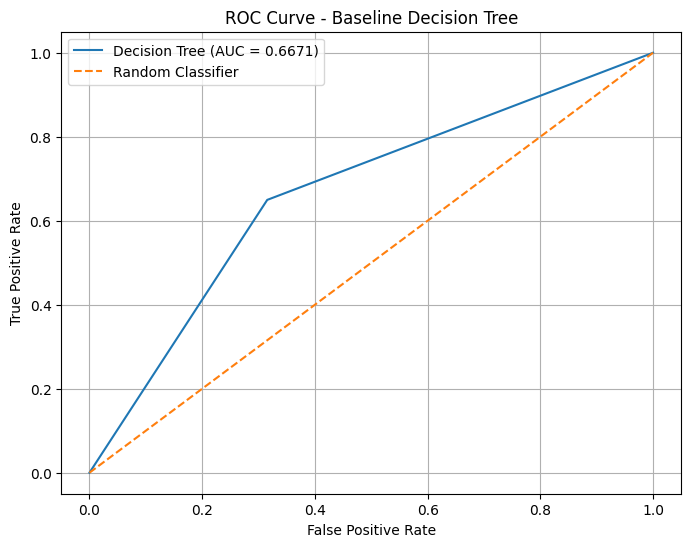

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_dt, tpr_dt, thresholds_dt = roc_curve(
    y_test_binary_dt,
    y_proba_left_dt
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {roc_auc_dt:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Decision Tree')
plt.legend()
plt.grid()
plt.show()

# Step 16: Decision Tree Hyperparameter Tuning

In [ ]:
from sklearn.metrics import make_scorer, f1_score

f1_left_scorer = make_scorer(
    f1_score,
    pos_label='Left'
)

print("Custom F1 Scorer Created Successfully")
print("Positive Class: Left")

Custom F1 Scorer Created Successfully
Positive Class: Left


In [ ]:
from sklearn.model_selection import GridSearchCV

# Decision Tree Parameter Grid
param_grid_dt = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [5, 10, 15, 20, None],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 5],
    'dt__max_features': [None, 'sqrt']
}

# Grid Search
grid_dt = GridSearchCV(
    estimator = baseline_dt,
    param_grid = param_grid_dt,
    cv = 5,
    scoring = f1_left_scorer,
    n_jobs = -1,
    verbose = 1
)

# Train
grid_dt.fit(X_train, y_train)

print("Decision Tree Hyperparameter Tuning Completed")
print("=" * 60)

print("Best Parameters:")
print(grid_dt.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_dt.best_score_:.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Decision Tree Hyperparameter Tuning Completed
Best Parameters:
{'dt__criterion': 'entropy', 'dt__max_depth': 5, 'dt__max_features': None, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}

Best Cross-Validation F1 Score:
0.7148


# Step 17: Tuned Decision Tree Predictions

In [ ]:
y_pred_tuned_dt = grid_dt.predict(X_test)

print('Tuned Decision Tree Predictions Generated Successfully')
print('=' * 60)
print('Number of Predictions:', len(y_pred_tuned_dt))
print('First 20 Predictions:', y_pred_tuned_dt[:20])

Tuned Decision Tree Predictions Generated Successfully
Number of Predictions: 11920
First 20 Predictions: ['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Stayed']


# Step 18: Tuned Decision Tree Performance

In [ ]:
accuracy_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
precision_tuned_dt = precision_score(y_test, y_pred_tuned_dt, pos_label= 'Left')
recall_tuned_dt = recall_score(y_test, y_pred_tuned_dt, pos_label= 'Left')
f1_tuned_dt = f1_score(y_test, y_pred_tuned_dt, pos_label= 'Left')

print('Tuned Decision Tree Performance')
print('=' * 50)
print(f'Accuracy : {accuracy_tuned_dt:.4f}')
print(f"Precision : {precision_tuned_dt:.4f}")
print(f"Recall : {recall_tuned_dt:.4f}")
print(f"F1 Score : {f1_tuned_dt:.4f}")

Tuned Decision Tree Performance
Accuracy : 0.7132
Precision : 0.6792
Recall : 0.7519
F1 Score : 0.7137


# Step 19: Tuned Decision Tree ROC-AUC

In [ ]:
y_proba_tuned_dt = grid_dt.predict_proba(X_test)

# Get probability of the 'Left' class
left_index_tuned_dt = list(grid_dt.classes_).index('Left')
y_proba_left_tuned_dt = y_proba_tuned_dt[:, left_index_tuned_dt]

# Convert target: Left = 1, Stayed = 0
y_test_binary_tuned_dt = (y_test == 'Left').astype(int)

# Calculate ROC-AUC
roc_auc_tuned_dt = roc_auc_score(
    y_test_binary_tuned_dt,
    y_proba_left_tuned_dt
)

print("Tuned Decision Tree ROC-AUC")
print("=" * 50)
print(f"ROC-AUC : {roc_auc_tuned_dt:.4f}")

Tuned Decision Tree ROC-AUC
ROC-AUC : 0.7850


# Step 20: Tuned Decision Tree ROC Curve

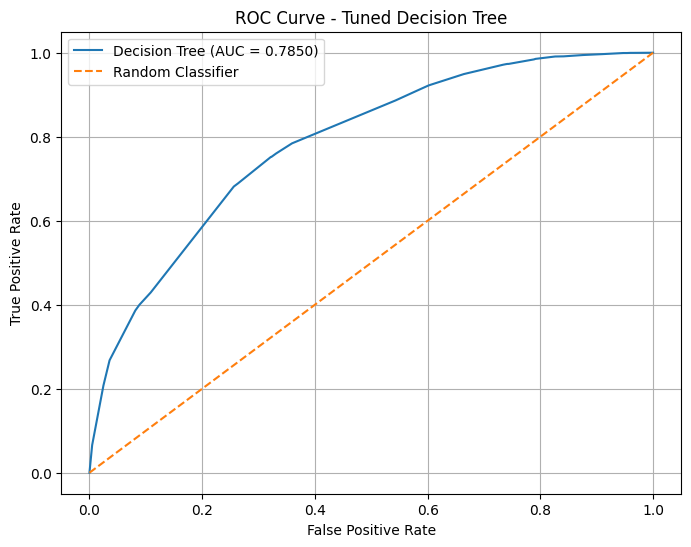

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_tuned_dt, tpr_tuned_dt, thresholds_tuned_dt = roc_curve(
    y_test_binary_tuned_dt,
    y_proba_left_tuned_dt
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_tuned_dt,
    tpr_tuned_dt,
    label = f'Decision Tree (AUC = {roc_auc_tuned_dt:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle = '--',
    label = 'Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Decision Tree')
plt.legend()
plt.grid()
plt.show()

# Step 21: Tuned Decision Tree Confusion Matrix

Tuned Decision Tree Confusion Matrix
[[4239 2013]
 [1406 4262]]

Total samples in confusion matrix: 11920


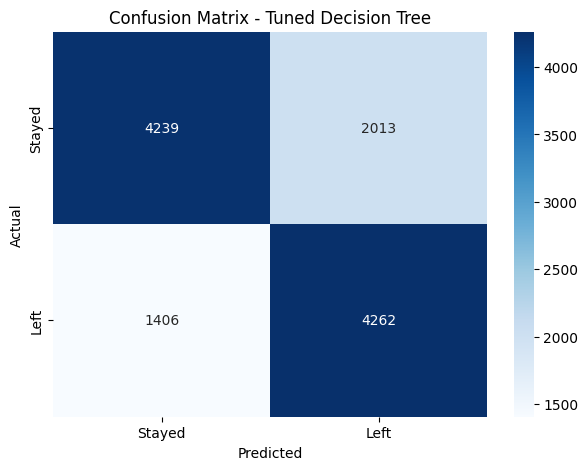

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_tuned_dt = confusion_matrix(
    y_test,
    y_pred_tuned_dt,
    labels = ['Stayed', 'Left']
)

print("Tuned Decision Tree Confusion Matrix")
print("=" * 60)
print(cm_tuned_dt)
print()
print("Total samples in confusion matrix:", cm_tuned_dt.sum())

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_tuned_dt,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = ['Stayed', 'Left'],
    yticklabels = ['Stayed', 'Left']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Decision Tree')
plt.show()

# Step 22: Tuned Decision Tree Classification Report

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report - Tuned Decision Tree")
print("=" * 60)
print(
    classification_report(
        y_test,
        y_pred_tuned_dt,
        labels = ['Stayed', 'Left'],
        target_names = ['Stayed', 'Left'],
        digits = 4
    )
)

Classification Report - Tuned Decision Tree
              precision    recall  f1-score   support

      Stayed     0.7509    0.6780    0.7126      6252
        Left     0.6792    0.7519    0.7137      5668

    accuracy                         0.7132     11920
   macro avg     0.7151    0.7150    0.7132     11920
weighted avg     0.7168    0.7132    0.7131     11920



# Step 23: Baseline vs Tuned Decision Tree


In [ ]:
print("Baseline vs Tuned Decision Tree")
print("=" * 60)

print(f"{'Metric':<15} {'Baseline':<15} {'Tuned':<15}")
print("-" * 60)

print(f"{'Accuracy':<15} {0.6680:<15.4f} {accuracy_tuned_dt:<15.4f}")
print(f"{'Precision':<15} {0.6512:<15.4f} {precision_tuned_dt:<15.4f}")
print(f"{'Recall':<15} {0.6496:<15.4f} {recall_tuned_dt:<15.4f}")
print(f"{'F1 Score':<15} {0.6504:<15.4f} {f1_tuned_dt:<15.4f}")
print(f"{'ROC-AUC':<15} {0.6671:<15.4f} {roc_auc_tuned_dt:<15.4f}")

Baseline vs Tuned Decision Tree
Metric          Baseline        Tuned          
------------------------------------------------------------
Accuracy        0.6680          0.7132         
Precision       0.6512          0.6792         
Recall          0.6496          0.7519         
F1 Score        0.6504          0.7137         
ROC-AUC         0.6671          0.7850         


# Step 24: Decision Tree Feature Importance

This is an important Decision Tree-specific part. We'll identify which employee attributes the tuned Decision Tree used most strongly for prediction.

Because your model is inside a preprocessing pipeline, we'll correctly extract the transformed feature names and the Decision Tree's feature_importances_.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the trained Decision Tree from the best pipeline
best_dt_model = grid_dt.best_estimator_

# Get preprocessing and model steps
preprocessor_dt = best_dt_model.named_steps['preprocessor']
dt_model = best_dt_model.named_steps['dt']

# Get transformed feature names
feature_names_dt = preprocessor_dt.get_feature_names_out()

# Get feature importance
feature_importance_dt = dt_model.feature_importances_

# Create DataFrame
importance_df_dt = pd.DataFrame({
    'Feature': feature_names_dt,
    'Importance': feature_importance_dt
})

# Sort by importance
importance_df_dt = importance_df_dt.sort_values(
    by='Importance',
    ascending=False
)

print("Decision Tree Feature Importance")
print("=" * 60)
print(importance_df_dt.head(15))

Decision Tree Feature Importance
                             Feature  Importance
38             cat__Job Level_Senior    0.295830
35        cat__Marital Status_Single    0.277922
43              cat__Remote Work_Yes    0.192915
36              cat__Job Level_Entry    0.055109
37                cat__Job Level_Mid    0.047729
15       cat__Work-Life Balance_Fair    0.046720
3          num__Number of Promotions    0.027171
42               cat__Remote Work_No    0.015981
16       cat__Work-Life Balance_Good    0.013102
14  cat__Work-Life Balance_Excellent    0.012165
17       cat__Work-Life Balance_Poor    0.007463
50      cat__Company Reputation_Good    0.003024
0                           num__Age    0.001771
4            num__Distance from Home    0.001585
2                num__Monthly Income    0.000977


Also remember: feature importance tells us how much the trained Decision Tree used a feature for splitting/prediction. It does not by itself establish that the feature causes employee attrition.

#  Step 25: Decision Tree Feature Importance Visualization

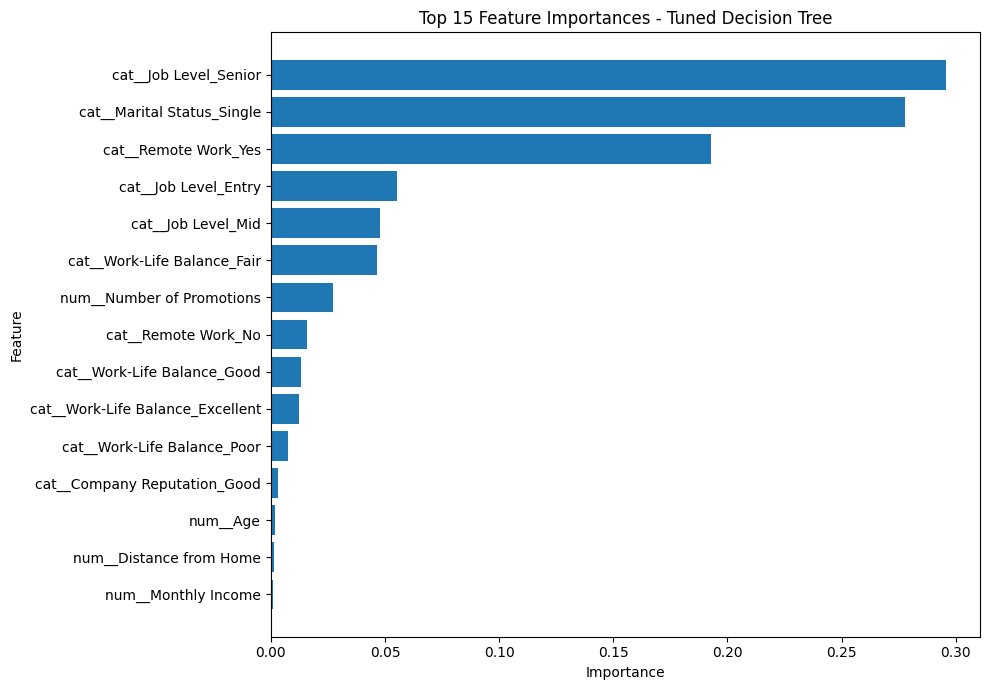

In [ ]:
top_features_dt = importance_df_dt.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features_dt['Feature'],
    top_features_dt['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Tuned Decision Tree')
plt.tight_layout()
plt.show()

# Step 26: New Employee Data for Decision Tree Prediction


In [ ]:
new_employee = pd.DataFrame({
    'Age': [30],
    'Gender': ['Male'],
    'Years at Company': [5],
    'Job Role': ['Technology'],
    'Monthly Income': [6000],
    'Work-Life Balance': ['Good'],
    'Job Satisfaction': ['High'],
    'Performance Rating': ['High'],
    'Number of Promotions': [1],
    'Overtime': ['No'],
    'Distance from Home': [10],
    'Education Level': ['Bachelor'],
    'Marital Status': ['Married'],
    'Number of Dependents': [2],
    'Job Level': ['Mid'],
    'Company Size': ['Medium'],
    'Company Tenure': [5],
    'Remote Work': ['Yes'],
    'Leadership Opportunities': ['Yes'],
    'Innovation Opportunities': ['Yes'],
    'Company Reputation': ['Good'],
    'Employee Recognition': ['High']
})

print("New Employee Data:")
print("=" * 50)
display(new_employee)

New Employee Data:


,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition
0,30,Male,5,Technology,6000,Good,High,High,1,No,...,Married,2,Mid,Medium,5,Yes,Yes,Yes,Good,High


# Step 27: Tuned Decision Tree Prediction

In [ ]:
y_pred_new = grid_dt.predict(new_employee)

print("New Employee Attrition Prediction")
print("=" * 50)
print("Prediction:", y_pred_new[0])

New Employee Attrition Prediction
Prediction: Stayed


# Step 28: Tuned Decision Tree Prediction Probabilities


In [ ]:
y_proba_new = grid_dt.predict_proba(new_employee)

print("Detailed Prediction Probabilities")
print("=" * 50)

for class_name, probability in zip(grid_dt.classes_, y_proba_new[0]):
    print(f"{class_name}: {probability:.6f}")

print("\nPrediction Probabilities:")
print(f"Left: {y_proba_new[0][list(grid_dt.classes_).index('Left')] * 100:.4f}%")
print(f"Stayed: {y_proba_new[0][list(grid_dt.classes_).index('Stayed')] * 100:.4f}%")

Detailed Prediction Probabilities
Left: 0.059497
Stayed: 0.940503

Prediction Probabilities:
Left: 5.9497%
Stayed: 94.0503%


# Step 29: Save the Tuned Decision Tree Model

In [ ]:
import joblib

# Save the complete tuned Decision Tree pipeline
joblib.dump(
    grid_dt.best_estimator_,
    'Employee_Attrition_Decision_Tree_Model.pkl'
)

print("Decision Tree Model Saved Successfully")
print("=" * 50)
print("File Name: Employee_Attrition_Decision_Tree_Model.pkl")

Decision Tree Model Saved Successfully
File Name: Employee_Attrition_Decision_Tree_Model.pkl


# Step 30: Load Saved Decision Tree Model

In [ ]:
import joblib

loaded_dt_model = joblib.load(
    'Employee_Attrition_Decision_Tree_Model.pkl'
)

print("Decision Tree Model Loaded Successfully")

Decision Tree Model Loaded Successfully


# Step 31: Prediction Using Loaded Decision Tree Model

In [ ]:
# Prediction Using Loaded Decision Tree Model

loaded_prediction = loaded_dt_model.predict(new_employee)

print("Loaded Decision Tree Model Prediction")
print("=" * 50)
print("Prediction:", loaded_prediction[0])

Loaded Decision Tree Model Prediction
Prediction: Stayed


In [ ]:
# Prediction Probabilities Using Loaded Model

loaded_probability = loaded_dt_model.predict_proba(new_employee)

print("Loaded Decision Tree Model Prediction Probabilities")
print("=" * 55)

for class_name, probability in zip(
    loaded_dt_model.classes_,
    loaded_probability[0]
):
    print(f"{class_name}: {probability:.6f}")

Loaded Decision Tree Model Prediction Probabilities
Left: 0.059497
Stayed: 0.940503
